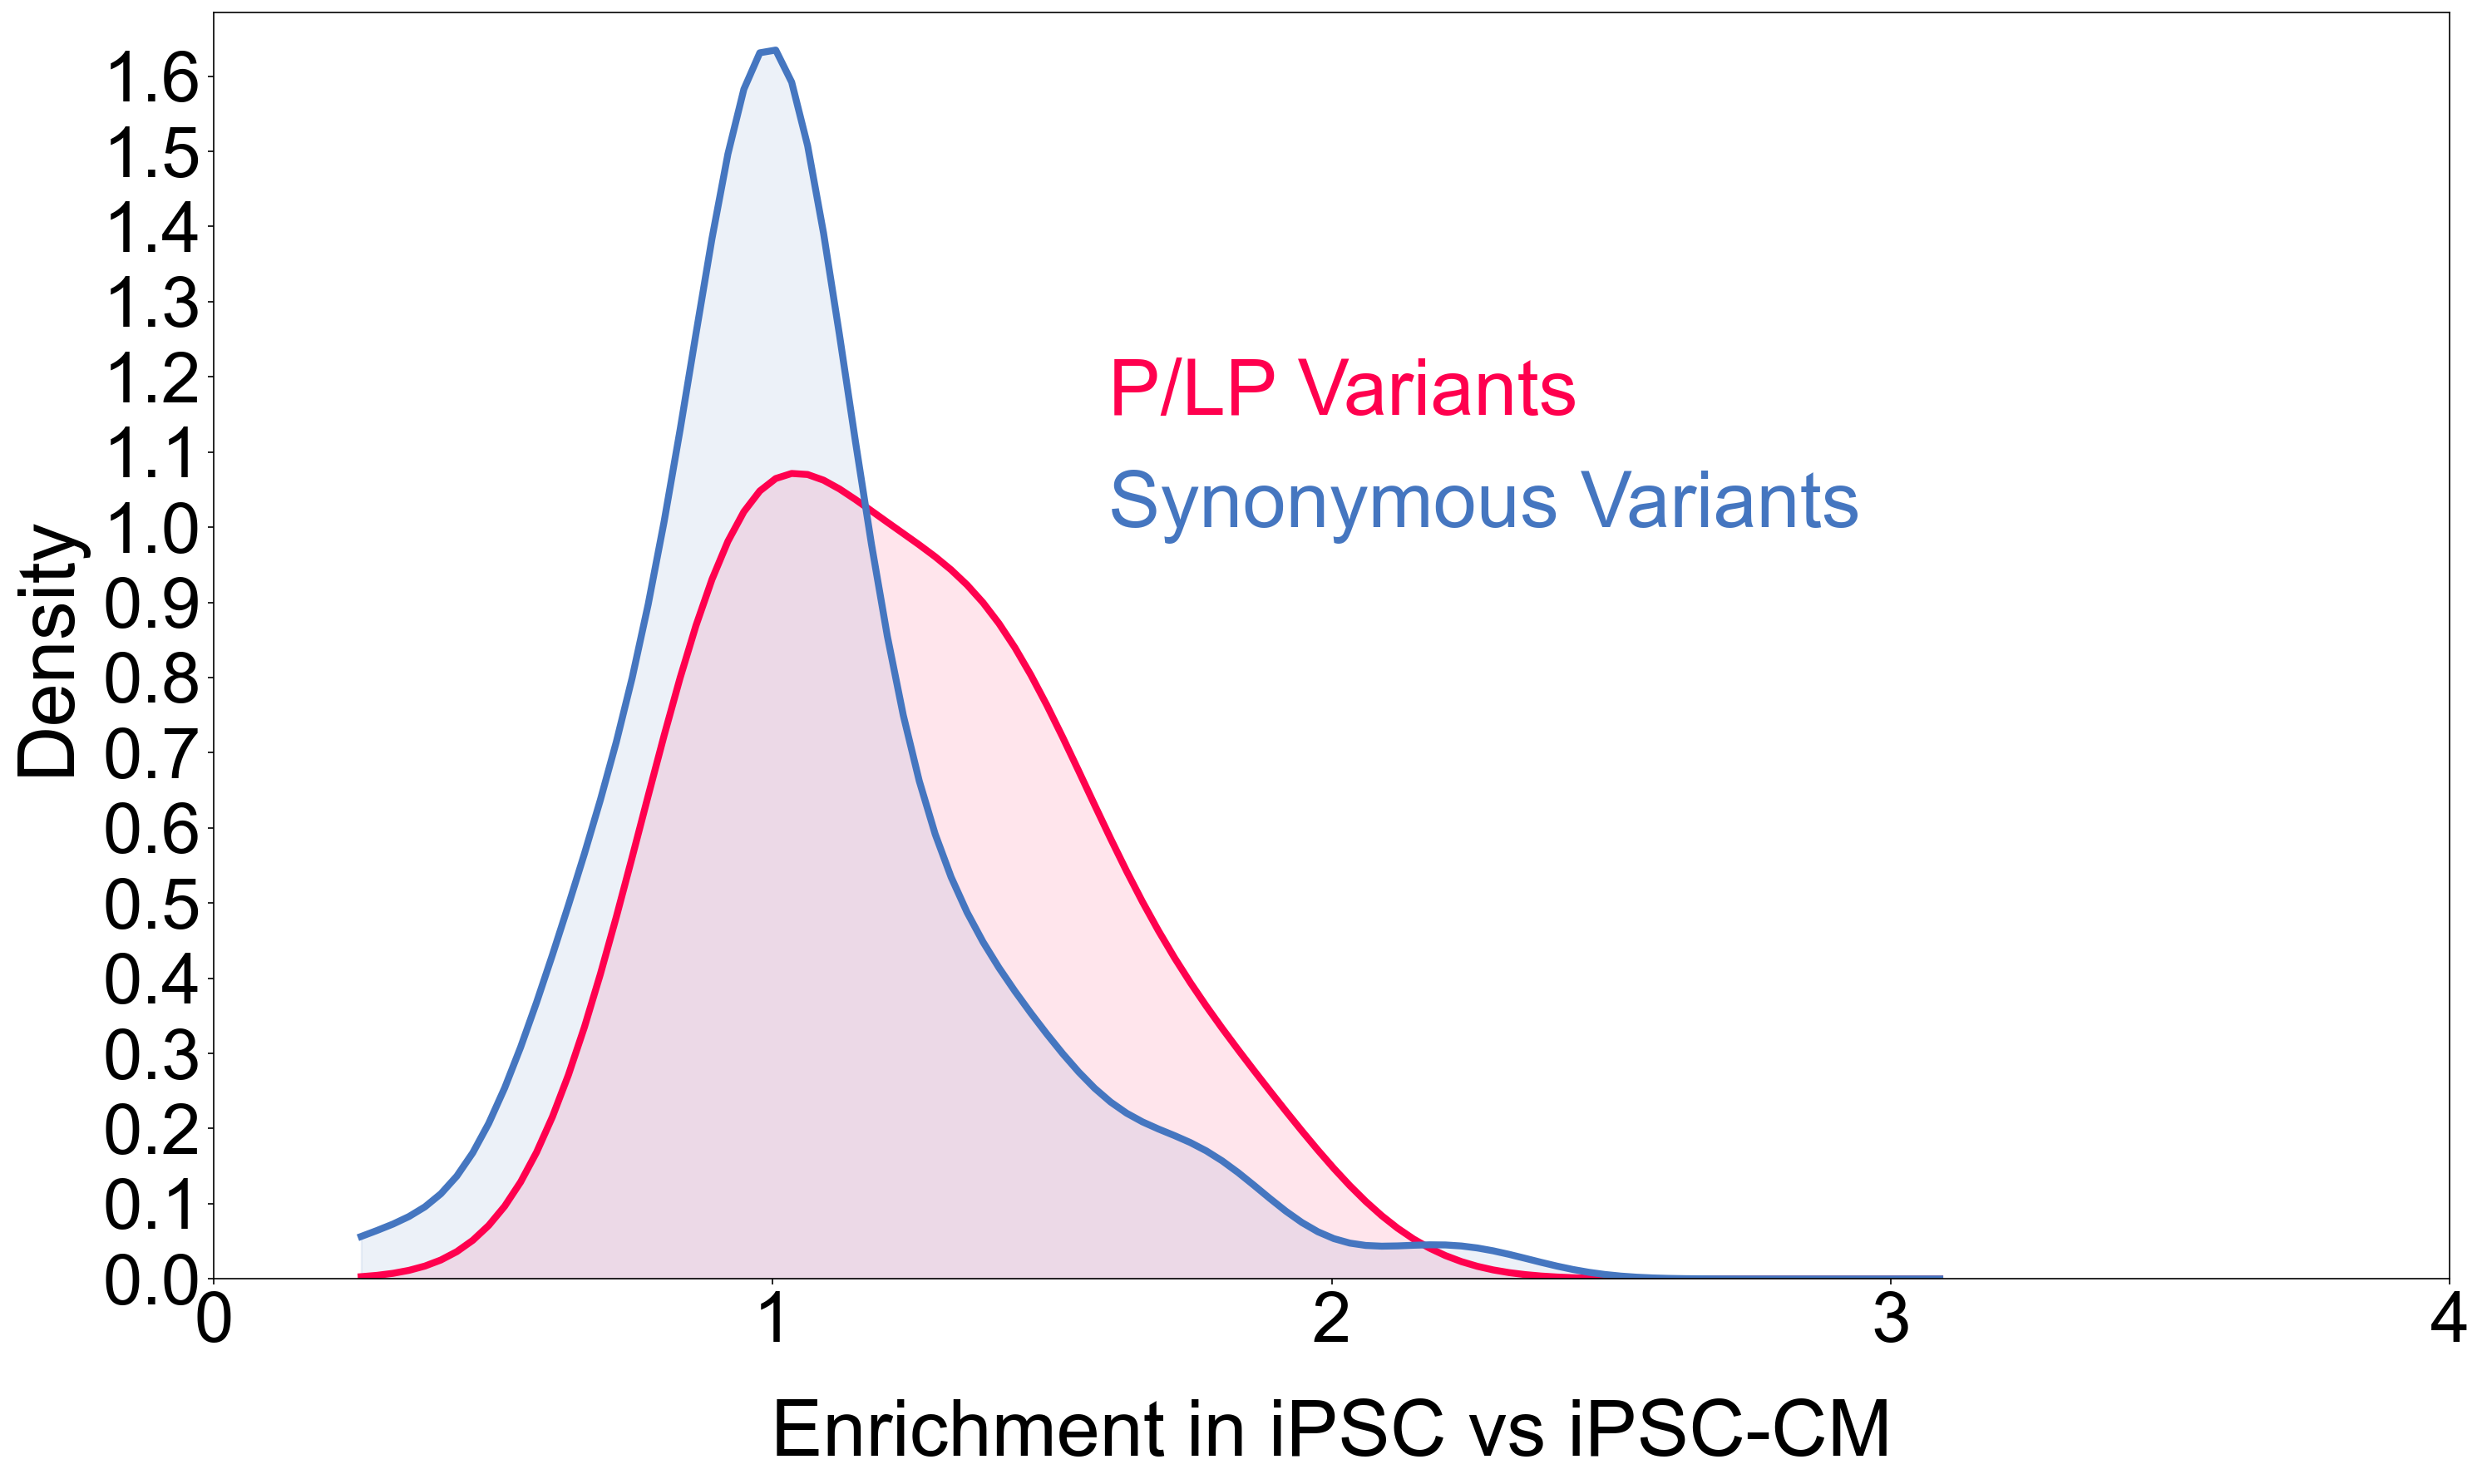

In [1]:
import numpy as  np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import scipy.stats as stats
from scipy.stats import gaussian_kde
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KernelDensity
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm, TwoSlopeNorm, ListedColormap, Normalize, LogNorm, SymLogNorm
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib as mpl
import os

# Set global font to Arial
mpl.rcParams['font.family'] = 'Arial'

ex = 9 

root_dir = f"/Users/kaiser19/Documents/RBM20/CX_debug_19Jan2026_MAF_iPSC_BC"

samples = "iPSC_vs_B_C"

merged_delta_proptest_dir = os.path.join(root_dir, f"Exon{ex}/Exon{ex}_R_Proptest_Results/Merged_Delta_Proptest")
plot_dir = os.path.join(root_dir, "Plots")
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)

merged_delta_proptest_file_path = os.path.join(merged_delta_proptest_dir, f"Ex{ex}_Merged_delta_proptest_by_SNV_{samples}.csv")
df = pd.read_csv(merged_delta_proptest_file_path)

samples_mod = samples.replace("_", "+")
samples_mod = samples_mod.replace("+vs+", " vs ")
# Filter to only retain Pathogenic dataset 
Pathogenic = df[df['PLP_Stopgain_Syn_VUS'] == 'Pathogenic']

# Filter to only retain Synonymous dataset
Synonymous = df[df['PLP_Stopgain_Syn_VUS'] == 'Synonymous']

# Plot using Kernel Density Estimation
plt.figure(figsize=(20, 12), dpi=150)

# Kernel Density Estimation for Pathogenic dataset
Pathogenic_kde = gaussian_kde(Pathogenic['delta_enrichment_closest_to_1'])
x_vals = np.linspace(min(df['delta_enrichment_closest_to_1']), max(df['delta_enrichment_closest_to_1']), 100)
pathogenic_density = Pathogenic_kde(x_vals)
plt.plot(x_vals, pathogenic_density, label='Pathogenic', color='#FF004E', linewidth=4)
plt.fill_between(x_vals, pathogenic_density, color='#FF004E', alpha=0.1) 

# Kernel Density Estimation for Synonymous dataset
Synonymous_kde = gaussian_kde(Synonymous['delta_enrichment_closest_to_1'])
synonymous_density = Synonymous_kde(x_vals)
plt.plot(x_vals, synonymous_density, label='Synonymous', color='#4576C0', linewidth=4)
plt.fill_between(x_vals, synonymous_density, color='#4576C0', alpha=0.1)

diff = pathogenic_density - synonymous_density
# Find where the sign of the difference changes
crossings = np.where(np.diff(np.sign(diff)))[0]
# Get the x-values of the intersection points
intersection_points = []
for idx in crossings:
    # Use linear interpolation between the two points surrounding the sign change
    x0, x1 = x_vals[idx], x_vals[idx + 1]
    y0, y1 = diff[idx], diff[idx + 1]

    # Linear interpolation to find approximate crossing
    if y1 - y0 != 0:
        x_cross = x0 - y0 * (x1 - x0) / (y1 - y0)
        intersection_points.append(x_cross)

# Plot x ticks according to max values of delta_enrichment_closest_to_1
plt.xticks(np.arange(0, max(df['delta_enrichment_closest_to_1'])+1, 1), fontsize=41)
plt.yticks(np.arange(0, max(synonymous_density)+0.1, 0.1), fontsize=41)
plt.ylim(0, max(pathogenic_density.max(), synonymous_density.max()) + 0.05)

# Graph labels and legend
plt.xlabel('Enrichment in iPSC vs iPSC-CM', fontsize=45, labelpad=25)
plt.ylabel('Density', fontsize=45, labelpad=10)
# plt.legend(bbox_to_anchor=(1, 1.01), loc='upper left', fontsize=40)
# plt.title(f'KDE for Pathogenic and Synonymous Variants based on Delta Enrichment CT1 Scores in {samples_mod}', fontsize=38, pad=50)

# plot "P/LP" and "Synonymous" labels on the plot
plt.text(1.6, 1.15, 'P/LP Variants', fontsize=45, color='#FF004E')
plt.text(1.6, 1, 'Synonymous Variants', fontsize=45, color='#4576C0')
# save the plot
plt.tight_layout()

# plot_path = os.path.join(plot_dir, f'RBM20_Ex{ex}_Density_Plot.png')
# plt.savefig(plot_path, dpi=150) 

# Show the plot
plt.show()


Optimal bandwidth for Pathogenic: 0.32442252252252246
Optimal bandwidth for Synonymous: 0.1082075075075075


/var/folders/9w/77c97mrd17b3mlvz9sszz9wh0000gp/T/ipykernel_86043/3311702648.py:47: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.xticks(np.arange(0, max(x_vals), 1), fontsize=11)


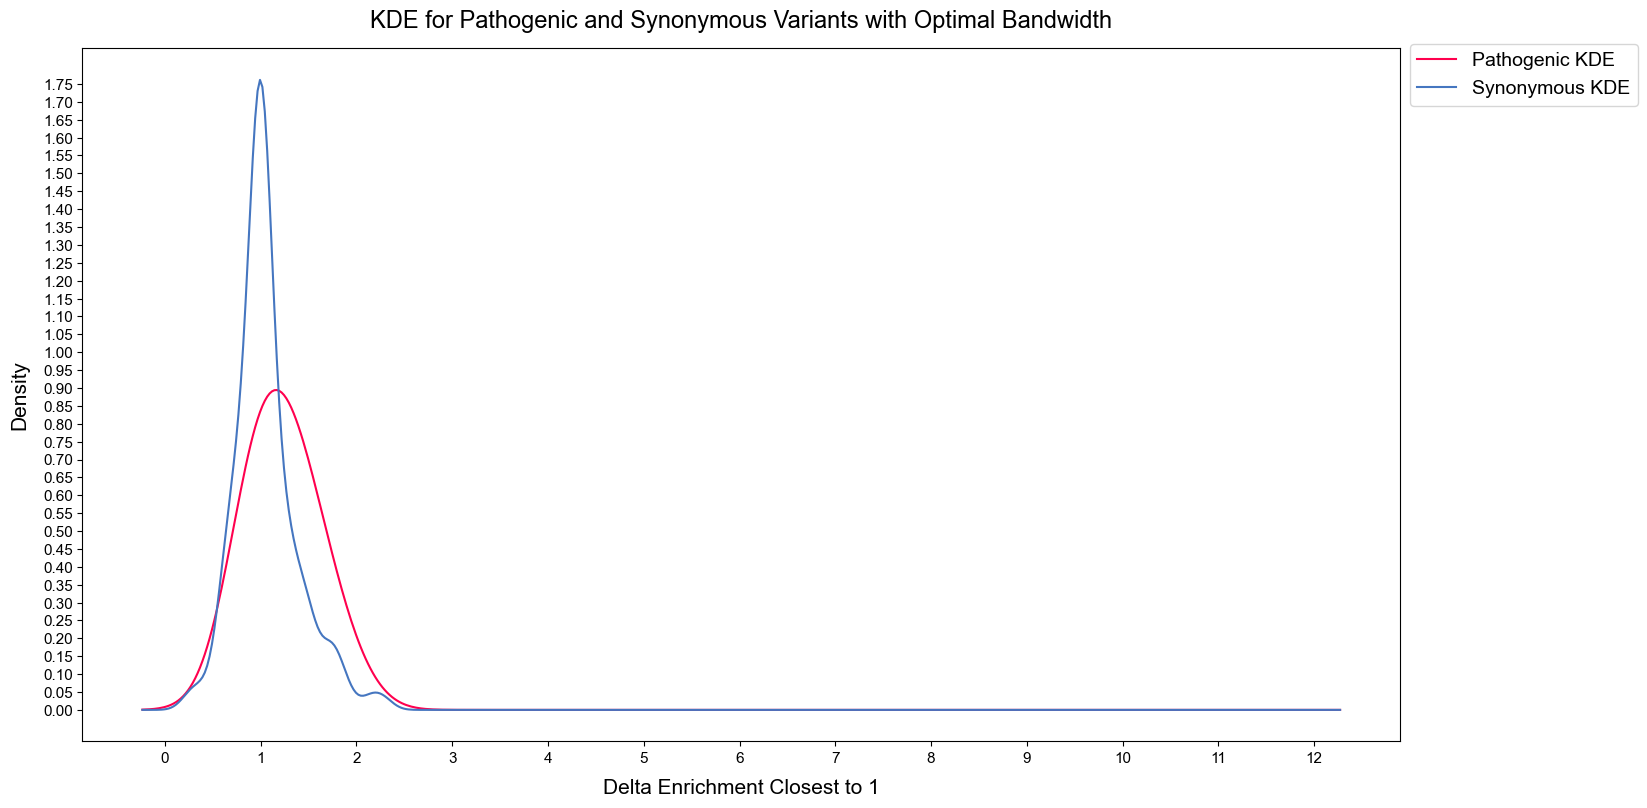

In [2]:
# Filter fresh Pathogenic and Synonymous data based on the PLP_Stopgain_Syn_VUS column
Pathogenic = df[df['PLP_Stopgain_Syn_VUS'] == 'Pathogenic']
Synonymous = df[df['PLP_Stopgain_Syn_VUS'] == 'Synonymous']    

# Convert the z_score_mean_BNP column to numpy arrays
Pathogenic = Pathogenic['delta_enrichment_closest_to_1'].dropna().values.reshape(-1, 1)
Synonymous = Synonymous['delta_enrichment_closest_to_1'].dropna().values.reshape(-1, 1)

# Define candidate bandwidths for GridSearchCV
bandwidths = np.linspace(0.0001, 18, 1000)


# Use GridSearchCV to select the optimal bandwidth for Pathogenic
grid_pathogenic = GridSearchCV(KernelDensity(kernel='gaussian'), {'bandwidth': bandwidths}, cv=5)
grid_pathogenic.fit(Pathogenic)
best_bandwidth_pathogenic = grid_pathogenic.best_params_['bandwidth']

# Use GridSearchCV to select the optimal bandwidth for Synonymous
grid_synonymous = GridSearchCV(KernelDensity(kernel='gaussian'), {'bandwidth': bandwidths}, cv=5)
grid_synonymous.fit(Synonymous)
best_bandwidth_synonymous = grid_synonymous.best_params_['bandwidth']

# Output the optimal bandwidths for both Pathogenic and Synonymous
print(f"Optimal bandwidth for Pathogenic: {best_bandwidth_pathogenic}")
print(f"Optimal bandwidth for Synonymous: {best_bandwidth_synonymous}")

# Calculate KDE using the optimal bandwidth for Pathogenic
Pathogenic_kde = KernelDensity(kernel='gaussian', bandwidth=best_bandwidth_pathogenic).fit(Pathogenic)

# Calculate KDE using the optimal bandwidth for Synonymous
Synonymous_kde = KernelDensity(kernel='gaussian', bandwidth=best_bandwidth_synonymous).fit(Synonymous)

# Define the range for the x-axis
x_vals = np.linspace(min(Pathogenic.min(), Synonymous.min()) - 0.5,
                     max(Pathogenic.max(), Synonymous.max()) + 10, 500).reshape(-1, 1)

# Compute the KDE scores for Pathogenic and Synonymous
Pathogenic_density = np.exp(Pathogenic_kde.score_samples(x_vals))
Synonymous_density = np.exp(Synonymous_kde.score_samples(x_vals))

# Plot the KDE curves for Pathogenic and Synonymous
plt.figure(figsize=(17, 9))
plt.plot(x_vals, Pathogenic_density, label='Pathogenic KDE', color='#FF004E')
plt.plot(x_vals, Synonymous_density, label='Synonymous KDE', color='#4576C0')

# set x tick intervals
plt.xticks(np.arange(0, max(x_vals), 1), fontsize=11)
plt.yticks(np.arange(0, max(Synonymous_density), 0.05), fontsize=11)

plt.xlabel('Delta Enrichment Closest to 1', fontsize=15, labelpad=10)
plt.ylabel('Density', fontsize=15, labelpad=10)
plt.title('KDE for Pathogenic and Synonymous Variants with Optimal Bandwidth', fontsize=17, pad=15)
plt.legend(bbox_to_anchor=(1, 1.02), loc='upper left', fontsize=14)
plt.show()


1st x where LLR crosses -0.5: 0.6580208618622716
2nd x where LLR crosses -0.5: 0.9271932462726945
All y=0 crossings: [1.15724077 2.16680822 2.64655215]
2nd y=0 crossing: 2.1668082211161055
Minimum LLR in intermediate range:
  x = 0.980659
  y = -0.542741


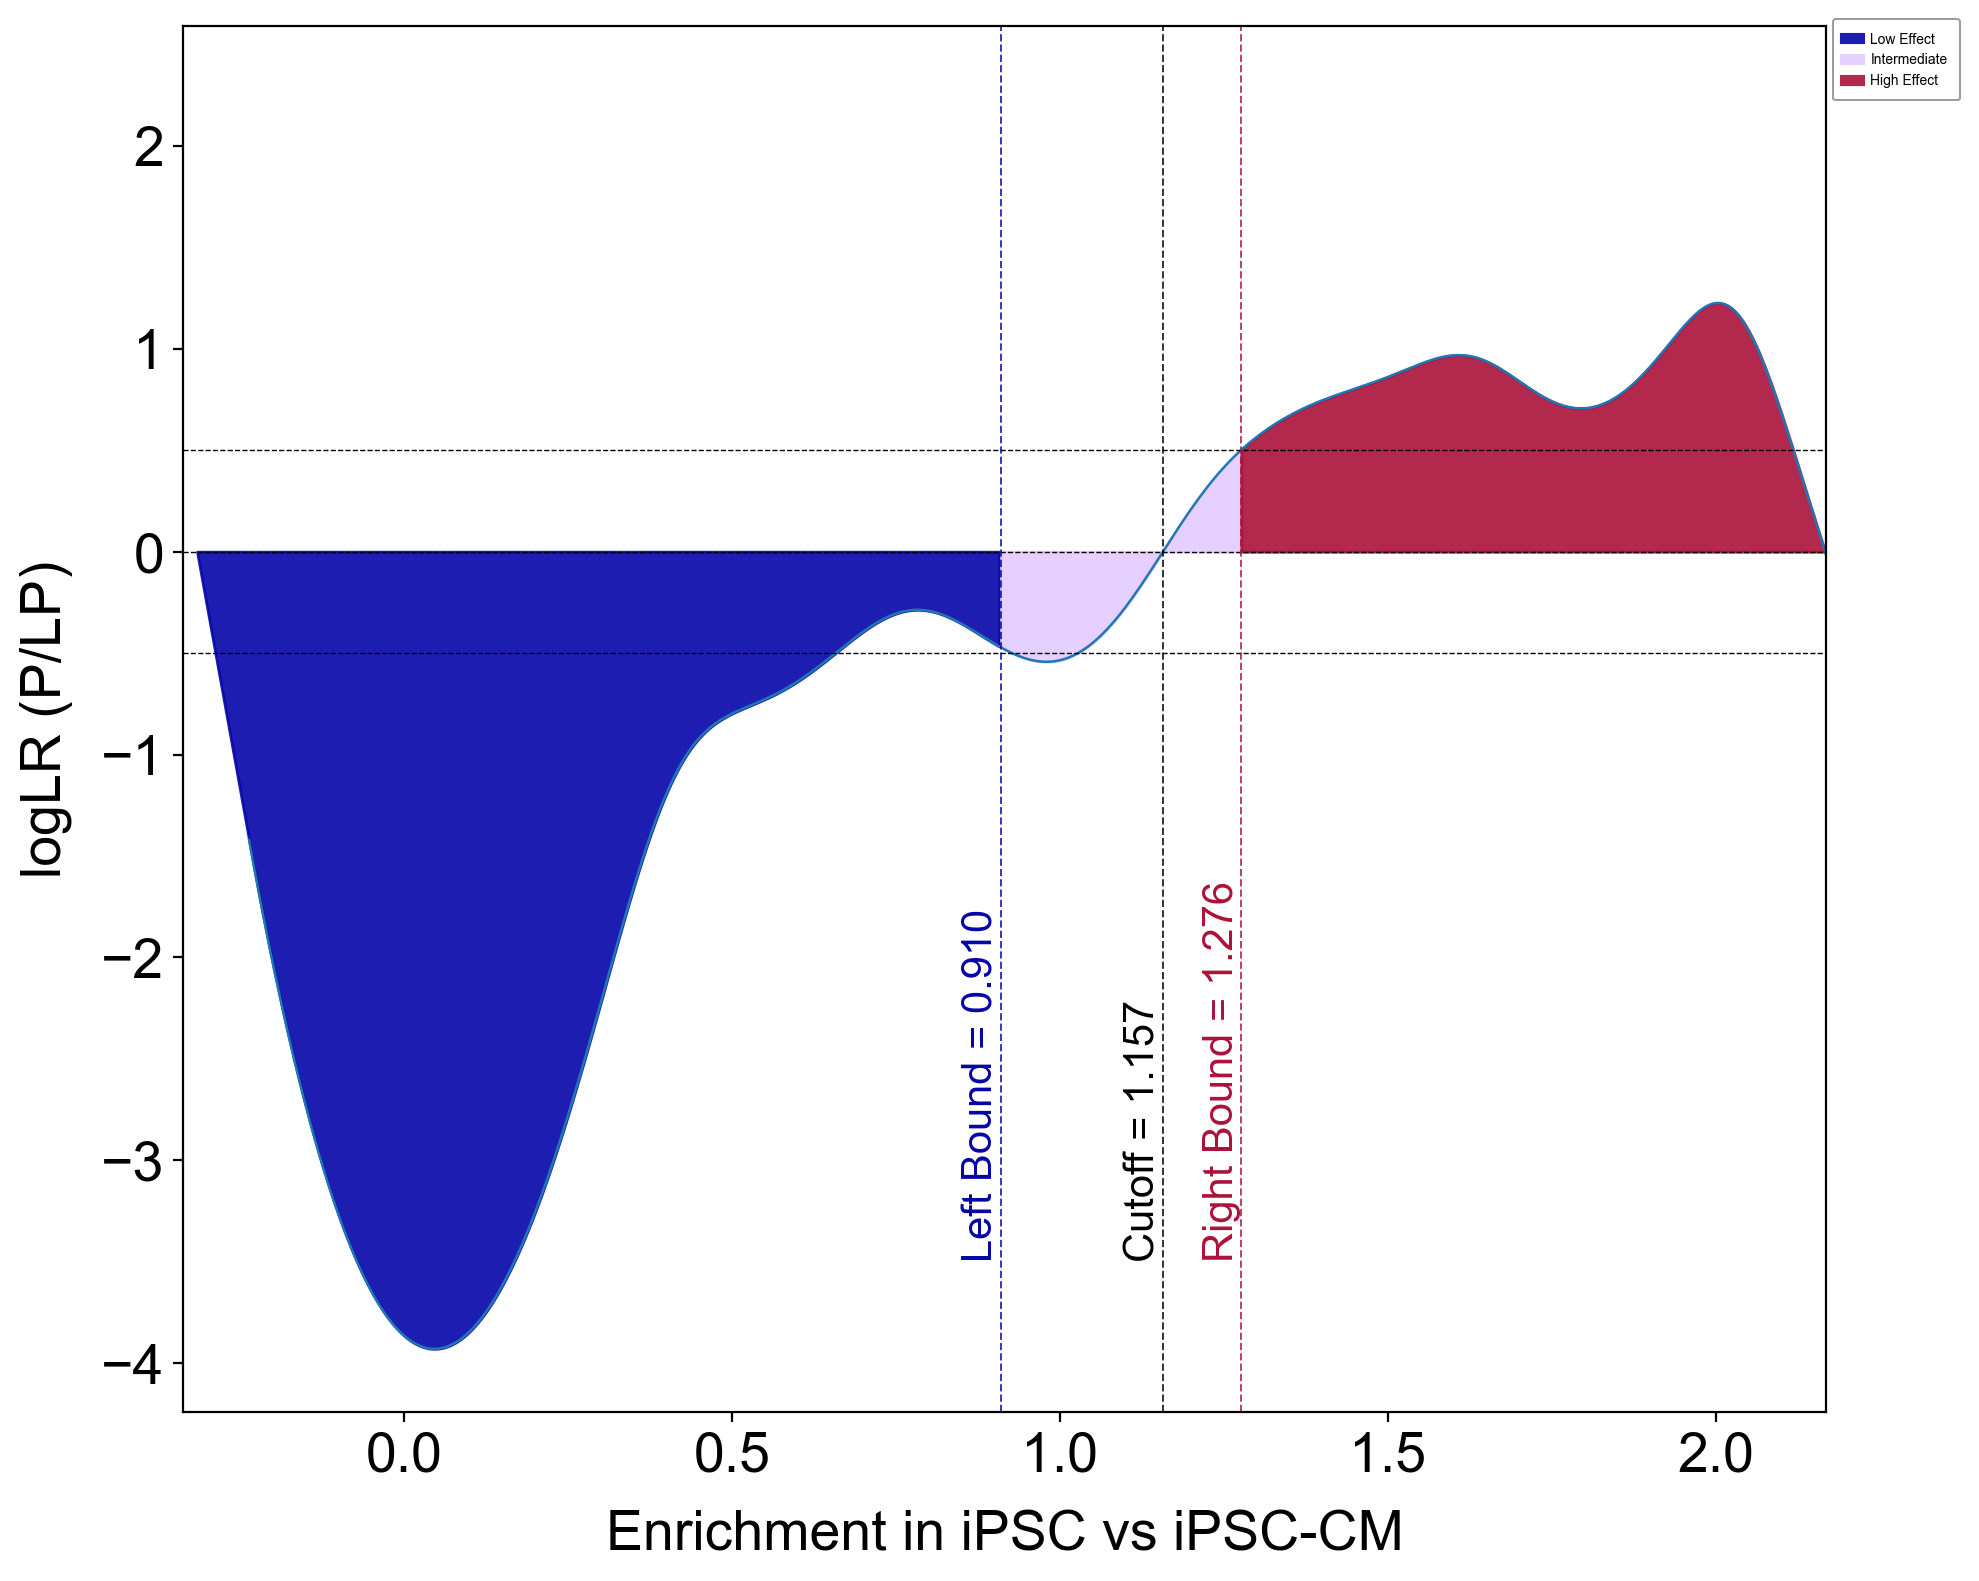

Cutoff (neg→pos zero): 1.157241
First crossing of LLR=-0.5: 0.6580208618622716
Intermediate range (x): [0.658021, 1.276045]
Synonymous (blue) x-range: [-0.236100, 0.658021]
Pathogenic (pink) x-range: [1.276045, 2.771930]


In [3]:
############################ FINAL LLR GRAPH FOR RBM20 ############################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV


ex = 9 

root_dir = f"/Users/kaiser19/Documents/RBM20/CX_debug_19Jan2026_MAF_iPSC_BC"

samples = "iPSC_vs_B_C"

merged_delta_proptest_dir = os.path.join(root_dir, f"Exon{ex}/Exon{ex}_R_Proptest_Results/Merged_Delta_Proptest")
plot_dir = os.path.join(root_dir, "Plots")
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)

merged_delta_proptest_file_path = os.path.join(merged_delta_proptest_dir, f"Ex{ex}_Merged_delta_proptest_by_SNV_{samples}.csv")

df = pd.read_csv(merged_delta_proptest_file_path)

# Filter sets
df_path = df[df["PLP_Stopgain_Syn_VUS"] == "Pathogenic"]
df_syn  = df[df["PLP_Stopgain_Syn_VUS"] == "Synonymous"]

# 1) Arrays
x_syn  = df_syn["delta_enrichment_closest_to_1"].dropna().to_numpy().reshape(-1, 1)
x_path = df_path["delta_enrichment_closest_to_1"].dropna().to_numpy().reshape(-1, 1)

# 2) KDEs (CV bandwidth)
def fit_kde_cv(x):
    q10, q90 = np.percentile(x, [10, 90])
    span = max(q90 - q10, 1e-6)
    grid = np.linspace(span / 50, span / 3, 15)
    gs = GridSearchCV(KernelDensity(kernel="gaussian"), {"bandwidth": grid}, cv=5)
    gs.fit(x)
    return gs.best_estimator_

kde_syn  = fit_kde_cv(x_syn)
kde_path = fit_kde_cv(x_path)

# 3) Grid
xmin = float(min(x_syn.min(), x_path.min())) - 0.5
xmax = float(max(x_syn.max(), x_path.max())) + 0.5
X = np.linspace(xmin, xmax, 1200).reshape(-1, 1)
x = X.ravel()

# 4) Densities & LLR
eps = 1e-12
p_syn  = np.exp(kde_syn.score_samples(X)) + eps
p_path = np.exp(kde_path.score_samples(X)) + eps
llr = np.log(p_path / p_syn)  # y-axis

# helper: linear interpolation for where (llr - yshift) crosses 0 between i..i+1
def interp_cross_llr(i, yshift=0.0):
    x0, x1 = x[i], x[i + 1]
    z0, z1 = (llr[i] - yshift), (llr[i + 1] - yshift)
    if z1 == z0:
        return np.nan
    return x0 - z0 * (x1 - x0) / (z1 - z0)

# 5) Cutoff: first neg→pos crossing of LLR=0
y0 = llr  # since target=0
signs0 = np.sign(y0)
signs0[signs0 == 0] = np.sign(np.nextafter(0, 1))
flip0 = np.where(np.diff(signs0) != 0)[0]

cutoff_point = None
for i in flip0:
    if (y0[i] < 0) and (y0[i + 1] > 0):
        cutoff_point = interp_cross_llr(i, yshift=0.0)
        break

if cutoff_point is None:
    # fallback: pick the first crossing if any, else midpoint
    crossings = np.array([interp_cross_llr(i, yshift=0.0) for i in flip0])
    crossings = crossings[np.isfinite(crossings)]
    cutoff_point = crossings.min() if crossings.size else 0.5 * (x.min() + x.max())

# index of cutoff on grid
jcut = np.searchsorted(x, cutoff_point, side="left")

yshift = -0.5
z = llr - yshift  # llr + 0.5

sgn = np.sign(z)
sgn[sgn == 0] = 1
idx = np.where(np.diff(sgn) != 0)[0]

first_cross = None
second_cross = None

if idx.size >= 1:
    first_cross = interp_cross_llr(idx[0], yshift=-0.5)
if idx.size >= 2:
    second_cross = interp_cross_llr(idx[1], yshift=-0.5)

print("1st x where LLR crosses -0.5:", first_cross)
print("2nd x where LLR crosses -0.5:", second_cross)


# 6b) Right bound: nearest crossing of LLR = +0.5 to the RIGHT of cutoff
yshift_p = +0.5
z_p = llr - yshift_p
sgn_p = np.sign(z_p)
sgn_p[sgn_p == 0] = 1
idx_p = np.where(np.diff(sgn_p) != 0)[0]
right_candidates = idx_p[idx_p >= jcut]

if right_candidates.size:
    inter_right = interp_cross_llr(right_candidates[0], yshift=+0.5)
else:
    inter_right = x.max()

# 6c) Replace inter_left with first_cross (your requested change)
if first_cross is not None:
    inter_left = first_cross
else:
    inter_left = x.min()  # fallback if no crossing found

# 7) Region masks from updated bounds
cond_inter = (x >= 0.91) & (x <= inter_right)
cond_syn   = (x < 0.91) # 0.91 is lowest ct1 for known patho variant
cond_path  = (x > inter_right)


def find_crossings(x, y, yshift=0.0):
    """
    Return all x positions where y crosses yshift (left->right),
    using linear interpolation on each segment.
    """
    z = y - yshift
    s = np.sign(z)
    # treat exact zeros as positive so they don't create weird double-crossings
    s[s == 0] = 1
    idx = np.where(np.diff(s) != 0)[0]

    crossings = []
    for i in idx:
        x0, x1 = x[i], x[i+1]
        z0, z1 = z[i], z[i+1]
        if z1 == z0:
            continue
        xc = x0 - z0 * (x1 - x0) / (z1 - z0)  # linear interp
        crossings.append(xc)
    return np.array(crossings)

# all crossings of y=0
cross0 = find_crossings(x, llr, yshift=0.0)

if cross0.size < 2:
    second_zero_cross = None
else:
    second_zero_cross = cross0[1]  # 2nd crossing from left to right

print("All y=0 crossings:", cross0)
print("2nd y=0 crossing:", second_zero_cross)

### find second red line i.e. lowest point of intermediate region
# restrict to intermediate region
x_inter   = x[cond_inter]
llr_inter = llr[cond_inter]

# index of minimum LLR within intermediate range
i_min = np.argmin(llr_inter)

x_min_inter = x_inter[i_min]
y_min_inter = llr_inter[i_min]

print(f"Minimum LLR in intermediate range:")
print(f"  x = {x_min_inter:.6f}")
print(f"  y = {y_min_inter:.6f}")


# 8) Plot
plt.figure(figsize=(10, 8), dpi=200)
plt.plot(x, llr, label="LLR = log p(Path)/p(Syn)", linewidth=0.9)

plt.axhline(0,    color="black", linestyle="--", linewidth=0.5)
plt.axhline(0.5,  color="black", linestyle="--", linewidth=0.5)
plt.axhline(-0.5, color="black", linestyle="--", linewidth=0.5)

# vertical lines
plt.axvline(cutoff_point, color="black", linestyle="--", linewidth=0.7, alpha=0.8)
plt.axvline(0.91,   color="xkcd:royal blue", linestyle="--", linewidth=0.7, alpha=0.8)              # plot line at x = 0.91 (lowest ct1 for known patho variant)
plt.axvline(inter_right,  color="xkcd:rouge",      linestyle="--", linewidth=0.7, alpha=0.8)

plt.text(0.91,  -3.5, f"Left Bound = {0.910:.3f}",  color="xkcd:royal blue", fontsize=15, verticalalignment="bottom", horizontalalignment="right", rotation=90)
plt.text(inter_right, -3.5, f"Right Bound = {inter_right:.3f}", color="xkcd:rouge", fontsize=15, verticalalignment="bottom", horizontalalignment="right", rotation=90)
plt.text(cutoff_point, -3.5, f"Cutoff = {cutoff_point:.3f}", color="black", fontsize=15, verticalalignment="bottom", horizontalalignment="right", rotation=90)
# plt.text(second_cross, -3, f"2nd Cross = {second_cross:.3f}", color="xkcd:green", fontsize=5, verticalalignment="bottom", horizontalalignment="right", rotation=90)
# plt.text(x_min_inter, -3, f"Min Inter = {x_min_inter:.3f}", color="xkcd:orange", fontsize=5, verticalalignment="bottom", horizontalalignment="right", rotation=90)

# fills
# For blue region: find where to start the extrapolation
x_syn_region = x[cond_syn]
llr_syn_region = llr[cond_syn]

if len(x_syn_region) > 0:
    # Find the leftmost point of the blue region
    x_start = x_syn_region[0]
    y_start = llr_syn_region[0]
    
    # Create a linear extrapolation back to y=0
    if y_start != 0:
        if len(x_syn_region) > 1:
            x1, y1 = x_syn_region[0], llr_syn_region[0]
            x2, y2 = x_syn_region[1], llr_syn_region[1]
            slope = (y2 - y1) / (x2 - x1) if (x2 - x1) != 0 else 0
            x_at_zero = x1 - y1 / slope if slope != 0 else x.min()
        else:
            x_at_zero = x.min()
        
        # Create extended arrays
        x_syn_extended = np.concatenate([[x_at_zero], x_syn_region])
        llr_syn_extended = np.concatenate([[0.0], llr_syn_region])
    else:
        x_syn_extended = x_syn_region
        llr_syn_extended = llr_syn_region
    
    plt.fill_between(x_syn_extended, llr_syn_extended, 0.0, alpha=0.9, color="xkcd:royal blue", label="Low Effect")
else:
    plt.fill_between(x, llr, 0.0, where=cond_syn, alpha=0.9, color="xkcd:royal blue", label="Low Effect")

plt.fill_between(x, llr, 0.0, where=cond_inter, alpha=0.9, color="xkcd:pale lilac", label="Intermediate")
plt.fill_between(x, llr, 0.0, where=cond_path,  alpha=0.9, color="xkcd:rouge",      label="High Effect")

plt.xlabel("Enrichment in iPSC vs iPSC-CM", fontsize=20, labelpad=10)
plt.ylabel("logLR (P/LP)", fontsize=20, labelpad=10)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

samples_mod = samples.replace("_", "+").replace("+vs+", " vs ")
# plt.title(f"Log Likelihood Ratio of RBM20 Variants' Effect on Pathogenicity in DCM of {samples_mod}", fontsize=25, pad=15)

# legend (your custom blocks)
handles = [
    plt.Line2D([0], [0], color="xkcd:royal blue", linewidth=4, alpha=0.9, label="Low Effect"),
    plt.Line2D([0], [0], color="xkcd:pale lilac", linewidth=4, alpha=0.9, label="Intermediate"),
    plt.Line2D([0], [0], color="xkcd:rouge",      linewidth=4, alpha=0.9, label="High Effect"),
]
legend = plt.legend(
    handles=handles,
    bbox_to_anchor=(1, 1.01),
    loc="upper left",
    fontsize=5,
    frameon=True,
    borderpad=0.9,
    handlelength=1,
    edgecolor="grey",
)
legend.get_frame().set_linewidth(0.7)

# (optional) plot x upper limit to only second zero crossing 
if second_zero_cross is not None:
    # plt.axvline(second_zero_cross, color="black", linestyle=":", linewidth=0.8, label=f"2nd y=0 @ {second_zero_cross:.3f}")
    plt.xlim(xmin-0.1, second_zero_cross+0.001)


plt.tight_layout()
# save fig
# plt.savefig(os.path.join(plot_dir, f'RBM20_Ex{ex}_LogLR_Plot.png'), dpi=200)
plt.show()

# 9) Print ranges
def fmt(a, b): 
    return f"[{a:.6f}, {b:.6f}]"

print(f"Cutoff (neg→pos zero): {cutoff_point:.6f}")
print(f"First crossing of LLR=-0.5: {first_cross if first_cross is not None else 'None'}")
print(f"Intermediate range (x): {fmt(inter_left, inter_right)}")
print(f"Synonymous (blue) x-range: {fmt(x.min(), inter_left)}")
print(f"Pathogenic (pink) x-range: {fmt(inter_right, x.max())}")



All assessed variants: 503


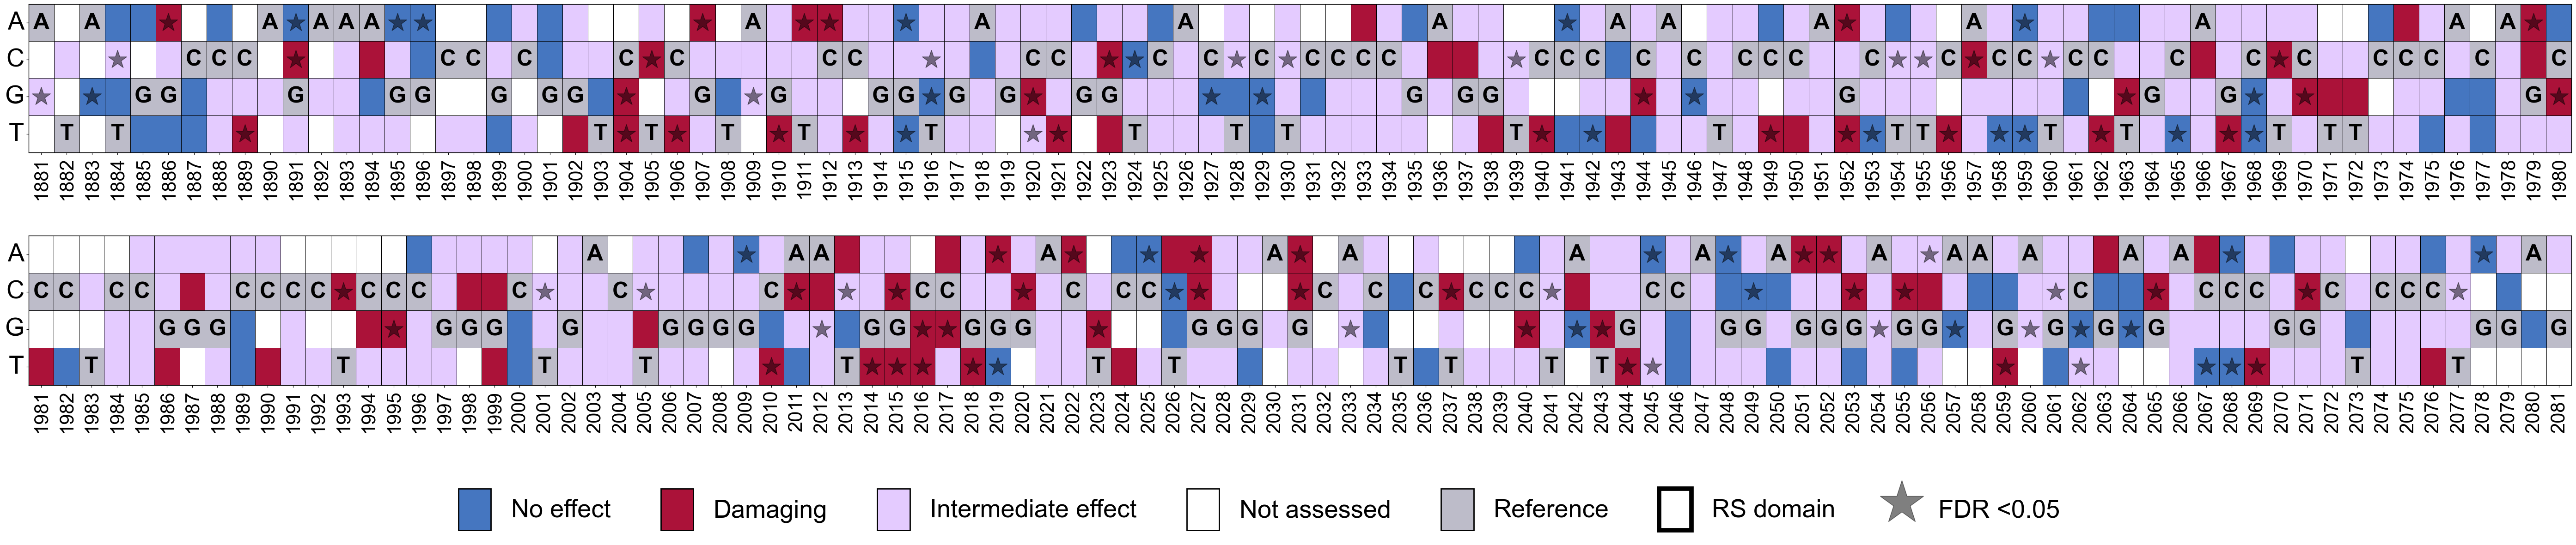

In [4]:
import os                                                                                                                                                                                                           
import pandas as pd                                       
import numpy as np                                                                                                                                                                                                  
import matplotlib.pyplot as plt                                                                                                                                                                                     
import seaborn as sns
from matplotlib.colors import ListedColormap, LinearSegmentedColormap, Normalize
import matplotlib.patches as patches
from matplotlib import gridspec


nine_exon_cdna_start = 1881
nine_exon_cdna_end = 2081
eleven_exon_cdna_start = 2656
eleven_exon_cdna_end = 2854

ex = 9
samples = "iPSC_vs_B+C"

root_dir = f"/Users/kaiser19/Documents/RBM20/CX_debug_19Jan2026_MAF_iPSC_BC"

merged_delta_proptest_dir = os.path.join(root_dir, f"Exon{ex}", f"Exon{ex}_R_Proptest_Results", "Merged_Delta_Proptest")

df = pd.read_csv(os.path.join(merged_delta_proptest_dir, f"Ex{ex}_Merged_delta_proptest_by_SNV_iPSC_vs_B_C.csv"))
df = df[["Variant1", "observed_nucleotide", "delta_enrichment_closest_to_1", "p_adj_ct1"]]
df = df.rename(columns={"Variant1": "SNV", "observed_nucleotide": "Observed_nucleotide", "p_adj_ct1": "p_adj_CT1(FDR)"})

pathogenic_min = 1.276
intermediate_min = 0.910
synonymous_max = 0.910

def classify_variant(value):
    if value > pathogenic_min:
        return 'Pathogenic'
    elif intermediate_min <= value <= pathogenic_min:
        return 'Intermediate'
    elif value < intermediate_min:
        return 'Synonymous'
    else:
        return 'Unknown'

df['LLR_Category'] = df['delta_enrichment_closest_to_1'].apply(classify_variant)

df['Position'] = df['SNV'].str.split('>').str[0].str[:-1].astype(int)
df = df.sort_values(by='Position')

# --- Load full variant range from reference transcript file ---
ref_df = pd.read_csv("/Users/kaiser19/Documents/RBM20/Data/RBM20_transcript_all_poss_vars_for_R_code.csv")
if ex == 9:
    ref_df = ref_df[
        (ref_df["cDNA (CDS)"] >= nine_exon_cdna_start) &
        (ref_df["cDNA (CDS)"] <= nine_exon_cdna_end)
    ].copy()
elif ex == 11:
    ref_df = ref_df[
    (ref_df["cDNA (CDS)"] >= eleven_exon_cdna_start) &
    (ref_df["cDNA (CDS)"] <= eleven_exon_cdna_end)
    ].copy()

# Build SNV strings matching the existing format: e.g. "2656G>A"
ref_df["SNV"] = ref_df["cDNA (CDS)"].astype(str) + ref_df["REF"] + ">" + ref_df["observed_nucleotide"]
ref_df["Position"] = ref_df["cDNA (CDS)"]
ref_df["Observed_nucleotide"] = ref_df["observed_nucleotide"]

# Separate reference alleles (REF=obs) from actual variants (REF!=obs)
ref_alleles = ref_df[ref_df["REF"] == ref_df["observed_nucleotide"]].copy()
alt_alleles = ref_df[ref_df["REF"] != ref_df["observed_nucleotide"]].copy()

# Create REF rows (grey cells) from reference alleles
ref_rows = pd.DataFrame({
    "SNV": ref_alleles["SNV"].values,
    "delta_enrichment_closest_to_1": 0.9765432123456789,
    "LLR_Category": "REF",
    "Position": ref_alleles["Position"].values,
    "Observed_nucleotide": ref_alleles["Observed_nucleotide"].values,
})

# Create placeholder rows for all possible alt variants not already in df
existing_snvs = set(df["SNV"].values)
missing_alts = alt_alleles[~alt_alleles["SNV"].isin(existing_snvs)].copy()
missing_rows = pd.DataFrame({
    "SNV": missing_alts["SNV"].values,
    "delta_enrichment_closest_to_1": np.nan,  # NaN -> white cells
    "LLR_Category": "Not_assessed",
    "Position": missing_alts["Position"].values,
    "Observed_nucleotide": missing_alts["Observed_nucleotide"].values,
})

# Combine: existing data + REF rows + missing variant placeholders
df = pd.concat([df, ref_rows, missing_rows], ignore_index=True)
df = df.sort_values(by=['Position', 'SNV']).reset_index(drop=True)

# Count assessed variants (excluding REF and Not_assessed rows)
assessed_all = df[
    (df['LLR_Category'] != 'REF') &
    (df['LLR_Category'] != 'Not_assessed') &
    (df['delta_enrichment_closest_to_1'].notna())
].shape[0]

print(f"All assessed variants: {assessed_all}")

# Pivot the DataFrame
heatmap_data = df.pivot(index='Observed_nucleotide', columns='Position', values='delta_enrichment_closest_to_1')

# Ensure full position range is present in columns
if ex == 9:
    full_positions = list(range(nine_exon_cdna_start, nine_exon_cdna_end + 1))
elif ex == 11:
    full_positions = list(range(eleven_exon_cdna_start, eleven_exon_cdna_end + 1))
heatmap_data = heatmap_data.reindex(columns=full_positions)

# Ensure all 4 nucleotides are present in rows
heatmap_data = heatmap_data.reindex(index=['A', 'C', 'G', 'T'])

# Define the ranges for the custom colormap (exclude REF sentinel from min/max)
real_vals = df.loc[df["LLR_Category"] != "REF", "delta_enrichment_closest_to_1"].dropna()
min_value = real_vals.min()
max_value = real_vals.max()

# Create colormaps
grey_ref_cmap = ListedColormap(["#BDBCC9"])
mask_ref = (heatmap_data == 0.9765432123456789)

total_range = max_value - min_value
synonymous_fraction = (synonymous_max - min_value) / total_range
pathogenic_fraction = (pathogenic_min - min_value) / total_range

colors = [
    (0, "#4576C0"),
    (synonymous_fraction, "#4576C0"),
    (synonymous_fraction, "xkcd:pale lilac"),
    (pathogenic_fraction, "xkcd:pale lilac"),
    (pathogenic_fraction, "xkcd:rouge"),
    (1, "xkcd:rouge")
]
segmented_cmap = LinearSegmentedColormap.from_list("custom_bwr", colors)
norm = Normalize(vmin=min_value, vmax=max_value)

# Create annotation matrix
annot_matrix = pd.DataFrame("", index=heatmap_data.index, columns=heatmap_data.columns)

for idx, row in df.iterrows():
    if row["LLR_Category"] == "REF":
        pos = row["Position"]
        obs_nuc = row["Observed_nucleotide"]
        if pos in heatmap_data.columns and obs_nuc in heatmap_data.index:
            annot_matrix.loc[obs_nuc, pos] = obs_nuc

annot_matrix = annot_matrix.fillna("").astype(str)

# Split the data into two ranges
all_positions = sorted(heatmap_data.columns.tolist())
n_positions = len(all_positions)

mid_index = n_positions // 2
split_point = all_positions[mid_index - 1]

heatmap_data_1 = heatmap_data.loc[:, heatmap_data.columns <= split_point]
heatmap_data_2 = heatmap_data.loc[:, heatmap_data.columns > split_point]

annot_matrix_1 = annot_matrix.loc[:, annot_matrix.columns <= split_point]
annot_matrix_2 = annot_matrix.loc[:, annot_matrix.columns > split_point]

mask_ref_1 = mask_ref.loc[:, mask_ref.columns <= split_point]
mask_ref_2 = mask_ref.loc[:, mask_ref.columns > split_point]

# Calculate heights proportionally based on number of columns
n_cols_1 = len(heatmap_data_1.columns)
n_cols_2 = len(heatmap_data_2.columns)
height_ratio = [n_cols_1, n_cols_2]

# Create figure with two subplots stacked vertically
fig = plt.figure(figsize=(71, 11))
gs = gridspec.GridSpec(2, 1, height_ratios=height_ratio, hspace=0.56)

# Helper function to create heatmap
def create_heatmap(ax, data, annot, mask_ref_data):
    # Mask for NaN cells (not assessed) — these will be white
    mask_nan = data.isna()
    # Combined mask: hide both NaN and REF from the main colormap heatmap
    mask_combined = mask_nan | mask_ref_data

    sns.heatmap(
        data,
        cmap=segmented_cmap,
        norm=norm,
        cbar=False,
        mask=mask_combined,
        annot=annot,
        fmt="",
        annot_kws={"size": 11, "weight": "bold", "color": "black", "ha": "center", "va": "center"},
        linewidths=0.5,
        linecolor='black',
        ax=ax
    )

    # Manually add annotations for REF cells
    for i in range(len(data.index)):
        for j in range(len(data.columns)):
            value = annot.iloc[i, j]
            if value != "":
                ax.text(
                    j + 0.5, i + 0.5, value,
                    ha="center", va="center", color="black", fontsize=35, weight='bold'
                )

    # Overlay grey heatmap for reference bases
    sns.heatmap(data, cmap=grey_ref_cmap, mask=~mask_ref_data, cbar=False,
                linewidths=0.5, linecolor='black', ax=ax)

    # Add spines
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)

# First heatmap - TOP
ax1 = plt.subplot(gs[0])
create_heatmap(ax1, heatmap_data_1, annot_matrix_1, mask_ref_1)

# Add FDR scatter points for first panel
y_labels = heatmap_data_1.index.tolist()
y_positions = {aa: i + 0.5 for i, aa in enumerate(y_labels)}
x_labels_1 = heatmap_data_1.columns.tolist()
x_positions_1 = {pos: i + 0.5 for i, pos in enumerate(x_labels_1)}

fdr_mask_1 = df[(df["p_adj_CT1(FDR)"] < 0.05) & (df["Position"] <= split_point)]
fdr_x_1 = [x_positions_1[pos] for pos in fdr_mask_1["Position"] if pos in x_positions_1]
fdr_y_1 = [y_positions[obs_aa] for obs_aa in fdr_mask_1["Observed_nucleotide"] if obs_aa in y_positions]

ax1.scatter(
    fdr_x_1, fdr_y_1,
    color="black", marker="*",
    s=900, edgecolors="black", linewidth=1,
    alpha=0.5, zorder=3
)

ax1.set_ylabel('', fontsize=40, labelpad=10)
ax1.tick_params(axis='y', labelsize=39, rotation=0)
ax1.tick_params(axis='x', labelsize=30, rotation=90)

# Second heatmap - BOTTOM
ax2 = plt.subplot(gs[1])
create_heatmap(ax2, heatmap_data_2, annot_matrix_2, mask_ref_2)

# Add FDR scatter points for second panel
x_labels_2 = heatmap_data_2.columns.tolist()
x_positions_2 = {pos: i + 0.5 for i, pos in enumerate(x_labels_2)}

fdr_mask_2 = df[(df["p_adj_CT1(FDR)"] < 0.05) & (df["Position"] > split_point)]
fdr_x_2 = [x_positions_2[pos] for pos in fdr_mask_2["Position"] if pos in x_positions_2]
fdr_y_2 = [y_positions[obs_aa] for obs_aa in fdr_mask_2["Observed_nucleotide"] if obs_aa in y_positions]

ax2.scatter(
    fdr_x_2, fdr_y_2,
    color="black", marker="*",
    s=900, edgecolors="black", linewidth=1,
    alpha=0.5, zorder=3
)

ax2.set_ylabel('', fontsize=40, labelpad=10)
ax2.set_xlabel('', fontsize=55, labelpad=10)
ax2.tick_params(axis='y', labelsize=39, rotation=0)
ax2.tick_params(axis='x', labelsize=30, rotation=90)

ax1.set_xlabel('')
ax2.set_xlabel('')
plt.subplots_adjust(bottom=0.1)

# Create custom legend
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.patches import Rectangle

legend_elements = [
    Rectangle((0, 0), 1, 1, facecolor='#4576C0', edgecolor='black', linewidth=2, label='No effect'),
    Rectangle((0, 0), 1, 1, facecolor='xkcd:rouge', edgecolor='black', linewidth=2, label='Damaging'),
    Rectangle((0, 0), 1, 1, facecolor='xkcd:pale lilac', edgecolor='black', linewidth=2, label='Intermediate effect'),
    Rectangle((0, 0), 1, 1, facecolor='white', edgecolor='black', linewidth=2, label='Not assessed'),
    Rectangle((0, 0), 1, 1, facecolor='#BDBCC9', edgecolor='black', linewidth=2, label='Reference'),
    Rectangle((0, 0), 1, 1, facecolor='white', edgecolor='black', linewidth=7, label='RS domain'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='black', markeredgecolor='black', markersize=71, alpha=0.5, label='FDR <0.05', linestyle='None')]

# Add legend below the bottom heatmap
fig.legend(handles=legend_elements,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.2),
        ncol=7,
        fontsize=39,
        frameon=False,
        fancybox=False,
        handlelength=1.3,
        handleheight=2.2)

plt.subplots_adjust(bottom=0.13)
# Save the plot
# plot_path = os.path.join(root_dir, "Plots", f"RBM20_Ex{ex}_CT1_Heatmap_of_SNVs_6Feb.png")
# plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()


     Var_p  delta_enrichment_closest_to_1     p_adj_ct1
0     A667                       1.133176  1.067010e-66
1    A667D                       0.939495  1.000000e+00
2    A667G                       0.787929  5.598381e-01
3    A667P                       1.414787  5.315629e-02
4    A667S                       1.312001  1.904397e-01
..     ...                            ...           ...
398  Y681C                       0.864338  6.830154e-07
399  Y681D                       1.136713  1.000000e+00
400  Y681H                       1.190612  5.529267e-05
401  Y681N                       0.999120  1.000000e+00
402  Y681S                       1.316290  1.768325e-01

[403 rows x 3 columns]
Total amino acid changes assessed (excluding ref=obs): 339


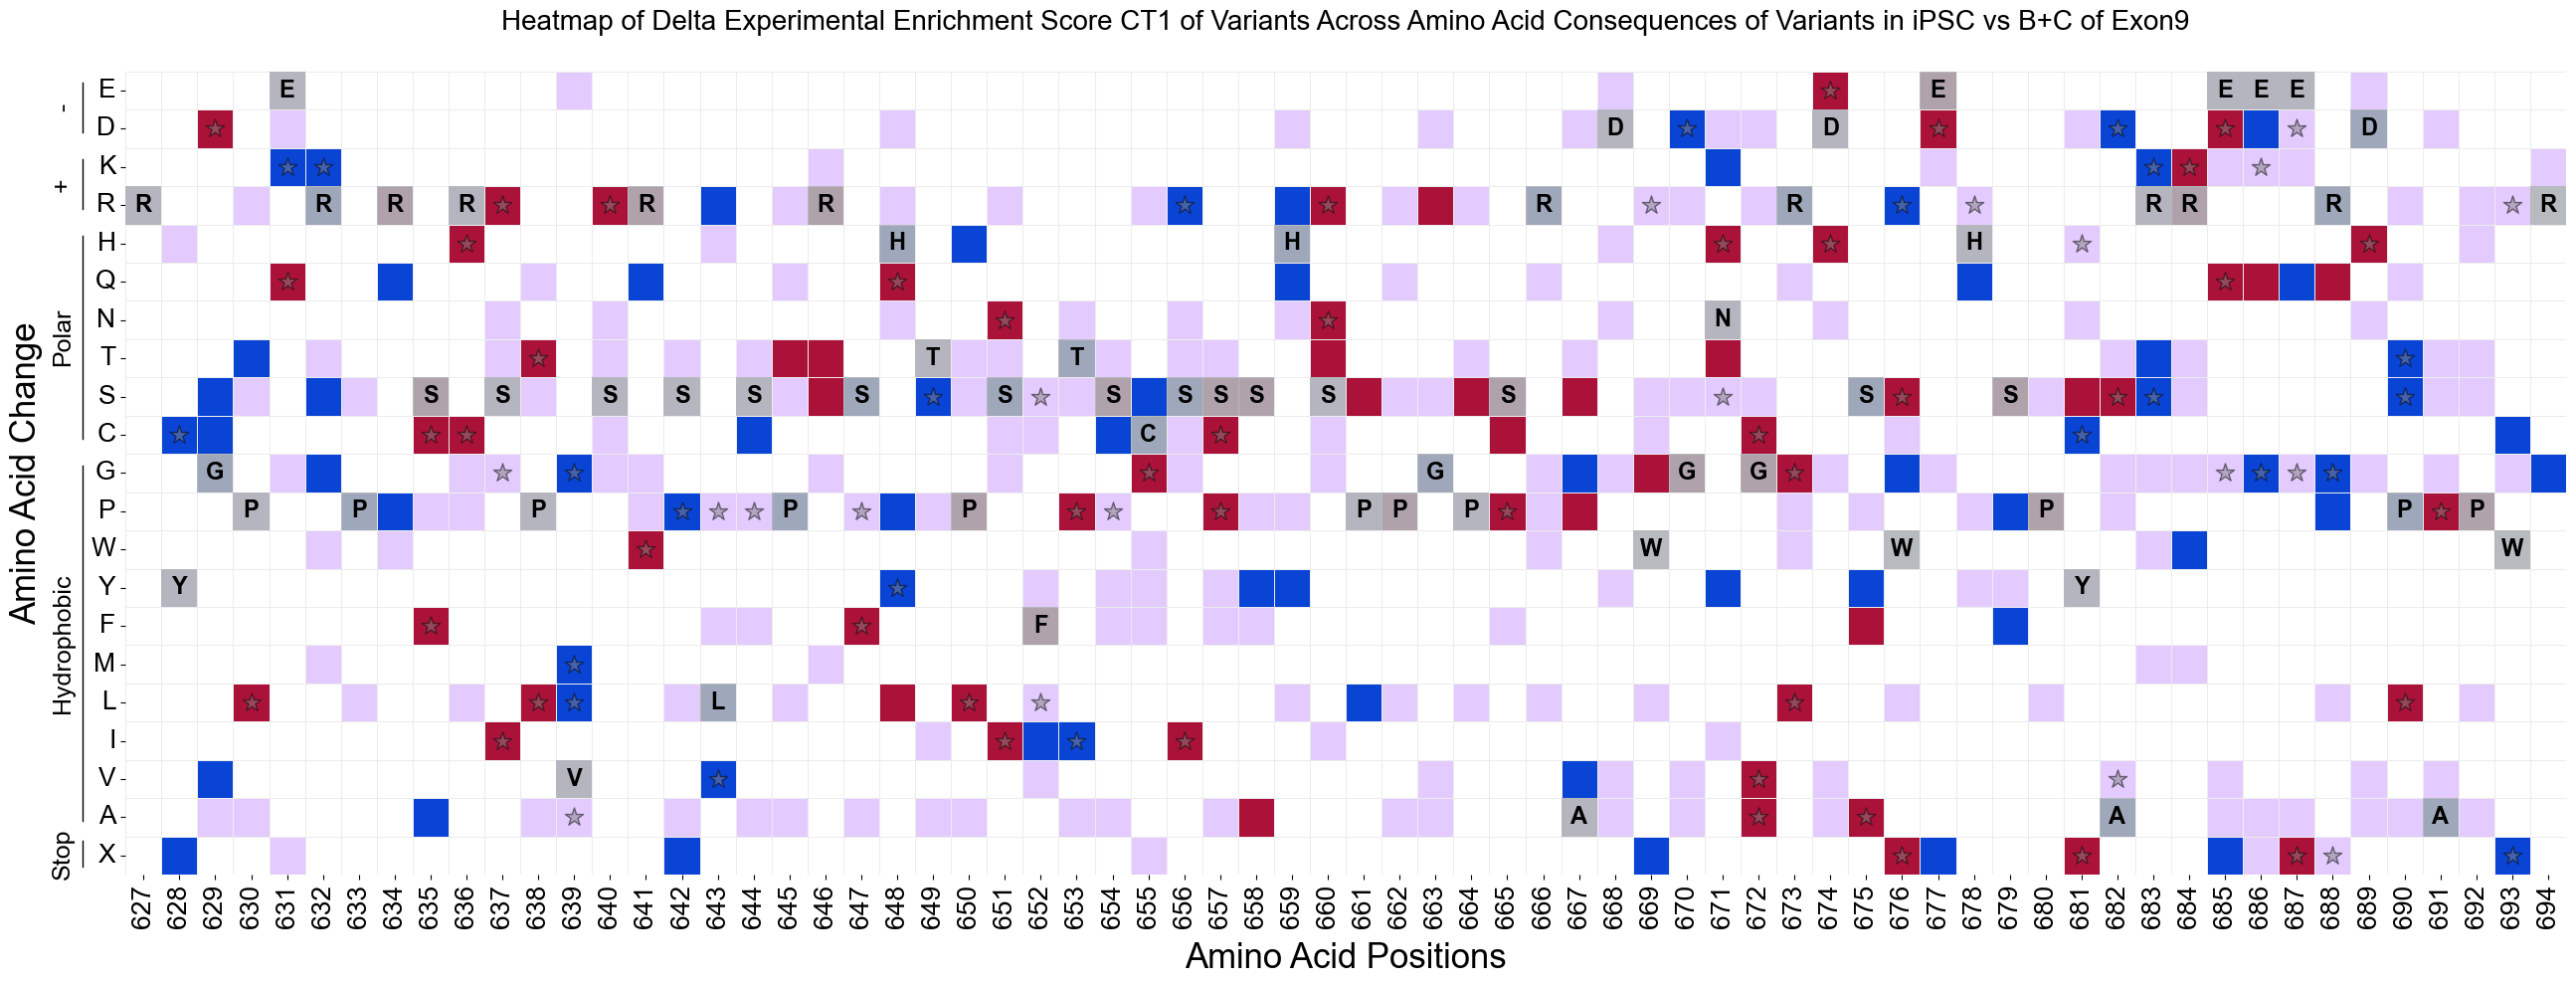

     Var_p  delta_enrichment_closest_to_1     p_adj_ct1  AA_pos ref_AA obs_AA
0     A667                       1.133176  1.067010e-66     667      A      A
1    A667D                       0.939495  1.000000e+00     667      A      D
2    A667G                       0.787929  5.598381e-01     667      A      G
3    A667P                       1.414787  5.315629e-02     667      A      P
4    A667S                       1.312001  1.904397e-01     667      A      S
..     ...                            ...           ...     ...    ...    ...
398  Y681C                       0.864338  6.830154e-07     681      Y      C
399  Y681D                       1.136713  1.000000e+00     681      Y      D
400  Y681H                       1.190612  5.529267e-05     681      Y      H
401  Y681N                       0.999120  1.000000e+00     681      Y      N
402  Y681S                       1.316290  1.768325e-01     681      Y      S

[403 rows x 6 columns]
Total amino acid changes assessed (exclu

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.patches as patches


ex = 9

root_dir = f"/Users/kaiser19/Documents/RBM20/CX_debug_19Jan2026_MAF_iPSC_BC"
merged_delta_proptest_dir = os.path.join(root_dir, f"Exon{ex}", f"Exon{ex}_R_Proptest_Results", "Merged_Delta_Proptest")
df = pd.read_csv(os.path.join(merged_delta_proptest_dir, f"Ex{ex}_Merged_delta_proptest_by_SNV_iPSC_vs_B_C.csv"))

df = df[["Var_p", "delta_enrichment_closest_to_1", "p_adj_ct1"]]

#replace 'p. ' in Var_p with ''
df['Var_p'] = df['Var_p'].str.replace('p.', '', regex=False)

df['delta_enrichment_closest_to_1'] = pd.to_numeric(df['delta_enrichment_closest_to_1'], errors='coerce')

# group by Var_p and take delta_enrichment_closest_to_1 with lowest p_adj_ct1
idx = df.groupby("Var_p")["p_adj_ct1"].idxmin()
df = df.loc[idx].reset_index(drop=True)

print(df)
df["AA_pos"] = df['Var_p'].str.extract(r'(\d+)').astype('Int64')
df['ref_AA'] = df['Var_p'].str[0]
df['obs_AA'] = df['Var_p'].str[-1]
#replace '*' in obs_AA with 'X'
df['obs_AA'] = df['obs_AA'].replace('*', 'X')

# if obs_AA is not a letter, replace with ref_AA value
df.loc[~df['obs_AA'].str.match(r'^[A-Z]$'), 'obs_AA'] = df['ref_AA']
assessed_aa = df[df["ref_AA"] != df["obs_AA"]].shape[0]
print(f"Total amino acid changes assessed (excluding ref=obs): {assessed_aa}")
# df.to_csv(f"/Users/kaiser19/Downloads/Exon{ex}_Mean_Exp_Enrichment_Heatmap.csv", index=False)

# intermediate_min = 0.910
# pathogenic_min = 1.276

# Get min/max of SD_exp_enrichment
min_val = df["delta_enrichment_closest_to_1"].min()
max_val = df["delta_enrichment_closest_to_1"].max()

# Define the critical breakpoints
low_threshold = 0.910
high_threshold = 1.276

# Normalize these values to range [0, 1]
low_norm = (low_threshold - min_val) / (max_val - min_val)
high_norm = (high_threshold - min_val) / (max_val - min_val)

# Define custom colormap
custom_cmap = LinearSegmentedColormap.from_list(
    "custom_cmap",
    [
        (0, "#0A44D5"),         # Dark Blue at min exp_enrichment
        (low_norm, "#0A44D5"),  # Dark Blue at 1.064148
        (low_norm, "xkcd:pale lilac"),  # pale lilac at 1.064148
        (high_norm, "xkcd:pale lilac"),  # stays pale lilac 1.266122
        (high_norm, "xkcd:rouge"),  # Light Pink at 1.266122
        (1, "xkcd:rouge"),      # Dark Red at max exp_enrichment
    ]
)

# Normalize the exp_enrichment values to scale from 0 to 1
norm = Normalize(vmin=df["delta_enrichment_closest_to_1"].min(), vmax=df["delta_enrichment_closest_to_1"].max())


all_aa = ['E', 'D', 'K', 'R', 'H', 'Q', 'N', 'T', 'S', 'C', 'G', 'P', 'W', 'Y', 'F', 'M', 'L', 'I', 'V', 'A', 'X']

# Define the full range of AA_pos values
min_aa_pos, max_aa_pos = df["AA_pos"].min(), df["AA_pos"].max()
full_aa_pos_range = list(range(min_aa_pos, max_aa_pos + 1))  # Ensures full x-axis coverage

# Pivot the dataframe to get a heatmap format
heatmap_data = df.pivot(index="obs_AA", columns="AA_pos", values="delta_enrichment_closest_to_1")

# **Reindex heatmap_data to ensure all AA_pos are present**
heatmap_data = heatmap_data.reindex(index=all_aa, columns=full_aa_pos_range, fill_value=np.nan)

# Create the heatmap with the custom colormap
plt.figure(figsize=(26, 10))
ax = sns.heatmap(
    heatmap_data,
    cmap=custom_cmap,        # Apply custom colormap
    annot=False,
    linewidths=0.5,
    linecolor="#ECECEC",
    cbar_kws={'label': 'Delta Experimental Enrichment Score CT1 (Lowest p_adj_ct1) of Variants', 'pad': 0.015},
    norm=norm  # Apply normalization to scale values properly
)

# **Fix: Convert categorical `obs_AA` values into numeric y-axis positions**
y_labels = heatmap_data.index.tolist()
y_positions = {aa: i + 0.5 for i, aa in enumerate(y_labels)}  # Centered positions

# **Fix: Map AA_pos to heatmap x-axis indices**
x_labels = heatmap_data.columns.tolist()  # Now this has the full range
x_positions = {pos: i + 0.5 for i, pos in enumerate(x_labels)}

aa_df = pd.read_csv(f"/Users/kaiser19/Documents/RBM20/Data/exon{ex}_totaldepths_mpileup.csv")
aa_df['Var_p'] = aa_df['Var_p'].str.replace('p.', '', regex=False)
aa_df['AA_pos'] = aa_df['Var_p'].str.extract(r'(\d+)').astype('Int64')
aa_df['AA_ref'] = aa_df['Var_p'].str[0]
aa_df = aa_df[['AA_pos', 'AA_ref']].drop_duplicates().reset_index(drop=True)

# Overlay reference amino acids as grey grids
for _, row in aa_df.iterrows():
    aa_pos, aa_ref = row["AA_pos"], row["AA_ref"]
    if aa_pos in x_positions and aa_ref in y_positions:
        x = x_positions[aa_pos] - 0.5  # Shift left by 0.5 for correct grid alignment
        y = y_positions[aa_ref] - 0.5  # Shift down by 0.5 for correct grid alignment
        rect = patches.Rectangle((x, y), 1, 1, linewidth=0, edgecolor=None, facecolor="#b0b3b8", alpha=0.9, zorder=2)
        ax.add_patch(rect)

        # Add text label (AA_ref)
        ax.text(
            x + 0.5, y + 0.5, aa_ref,  # Center text in the cell
            ha="center", va="center", fontsize=17, color="black", zorder=3, weight='bold'
        )

df_copy = df.copy()
# remove rows where ref_AA obs_AA are the same
df_copy = df_copy[df_copy["ref_AA"] != df_copy["obs_AA"]]
# Get data for FDR < 0.05
fdr_mask = df_copy[df_copy["p_adj_ct1"] < 0.05]

# Convert categorical obs_AA and AA_pos to heatmap x/y indices
fdr_x = [x_positions[pos] for pos in fdr_mask["AA_pos"] if pos in x_positions]
fdr_y = [y_positions[aa] for aa in fdr_mask["obs_AA"] if aa in y_positions]

# **Fix: Overlay scatter points at correct grid coordinates**
ax.scatter(
    fdr_x, fdr_y,
    color="grey", marker="*",
    s=190, edgecolors="black", linewidth=1,
    alpha=0.5,
    label="FDR < 0.05", zorder=3
)
    
# Formatting
plt.xlabel("Amino Acid Positions", fontsize=25, labelpad=10)
plt.ylabel("Amino Acid Change", fontsize=25, labelpad=35)
plt.title(f"Heatmap of Delta Experimental Enrichment Score CT1 of Variants Across Amino Acid Consequences of Variants in iPSC vs B+C of Exon{ex}", fontsize=20, pad=30)
plt.xticks(rotation=90, fontsize=19)
plt.yticks(rotation=0, fontsize=19)

# Define amino acid groups for vertical lines
vertical_groups = {
    "-": ['D', 'E'],
    "+": ['K', 'R'],
    "Polar": ['H', 'Q', 'N', 'T', 'S', 'C'],
    "Hydrophobic": ['G', 'P', 'W', 'Y', 'F', 'M', 'L', 'I', 'V', 'A'],
    "Stop": ['X']  # Formerly '*'
}

# Define the x-coordinate for vertical lines (adjust leftwards so they don't overlap with y-axis labels)
x_vline = min(x_positions.values()) - 1.7  # Shift left further

for i, (group, aa_list) in enumerate(vertical_groups.items()):
    # Get min and max y-positions for the amino acids in this group
    y_min = min(y_positions[aa] for aa in aa_list) - 0.2
    y_max = max(y_positions[aa] for aa in aa_list) + 0.1
    
    # **Special case for "Stop" to force it in**
    if group == "Stop":
        y_min -= 0.2  # Small downward shift to ensure visibility
        y_max += 0.2  # Small upward shift to ensure it appears

    # Draw vertical line at the same x_vline
    ax.plot([x_vline, x_vline], [y_min, y_max], color="black", linewidth=1, clip_on=False)

    # Add rotated text labels next to each vertical line
    ax.text(
        x_vline - 0.54,  # Shift text slightly left
        (y_min + y_max) / 2,  # Center text within the span
        group,
        fontsize=18, va="center", ha="center", rotation=90  # Rotate text to align with vertical line
    )

#remove colorbar
ax.collections[0].colorbar.remove()
#save as pdf
plt.tight_layout()
# plot_path = Path(root_dir) / "Plots"/f"RBM20_Exon{ex}_CT1_AA_Heatmap.pdf"
# plt.savefig(plot_path, dpi=300, bbox_inches='tight')
# Show the plot
plt.show()

print(df)
assessed_aa = df[df["ref_AA"] != df["obs_AA"]].shape[0]
print(f"Total amino acid changes assessed (excluding ref=obs): {assessed_aa}")
# total number of amino acid changes assessed? excluding aa changes where ref_AA = obs_AA